In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv('df_with_topics_and_sentiments.csv')

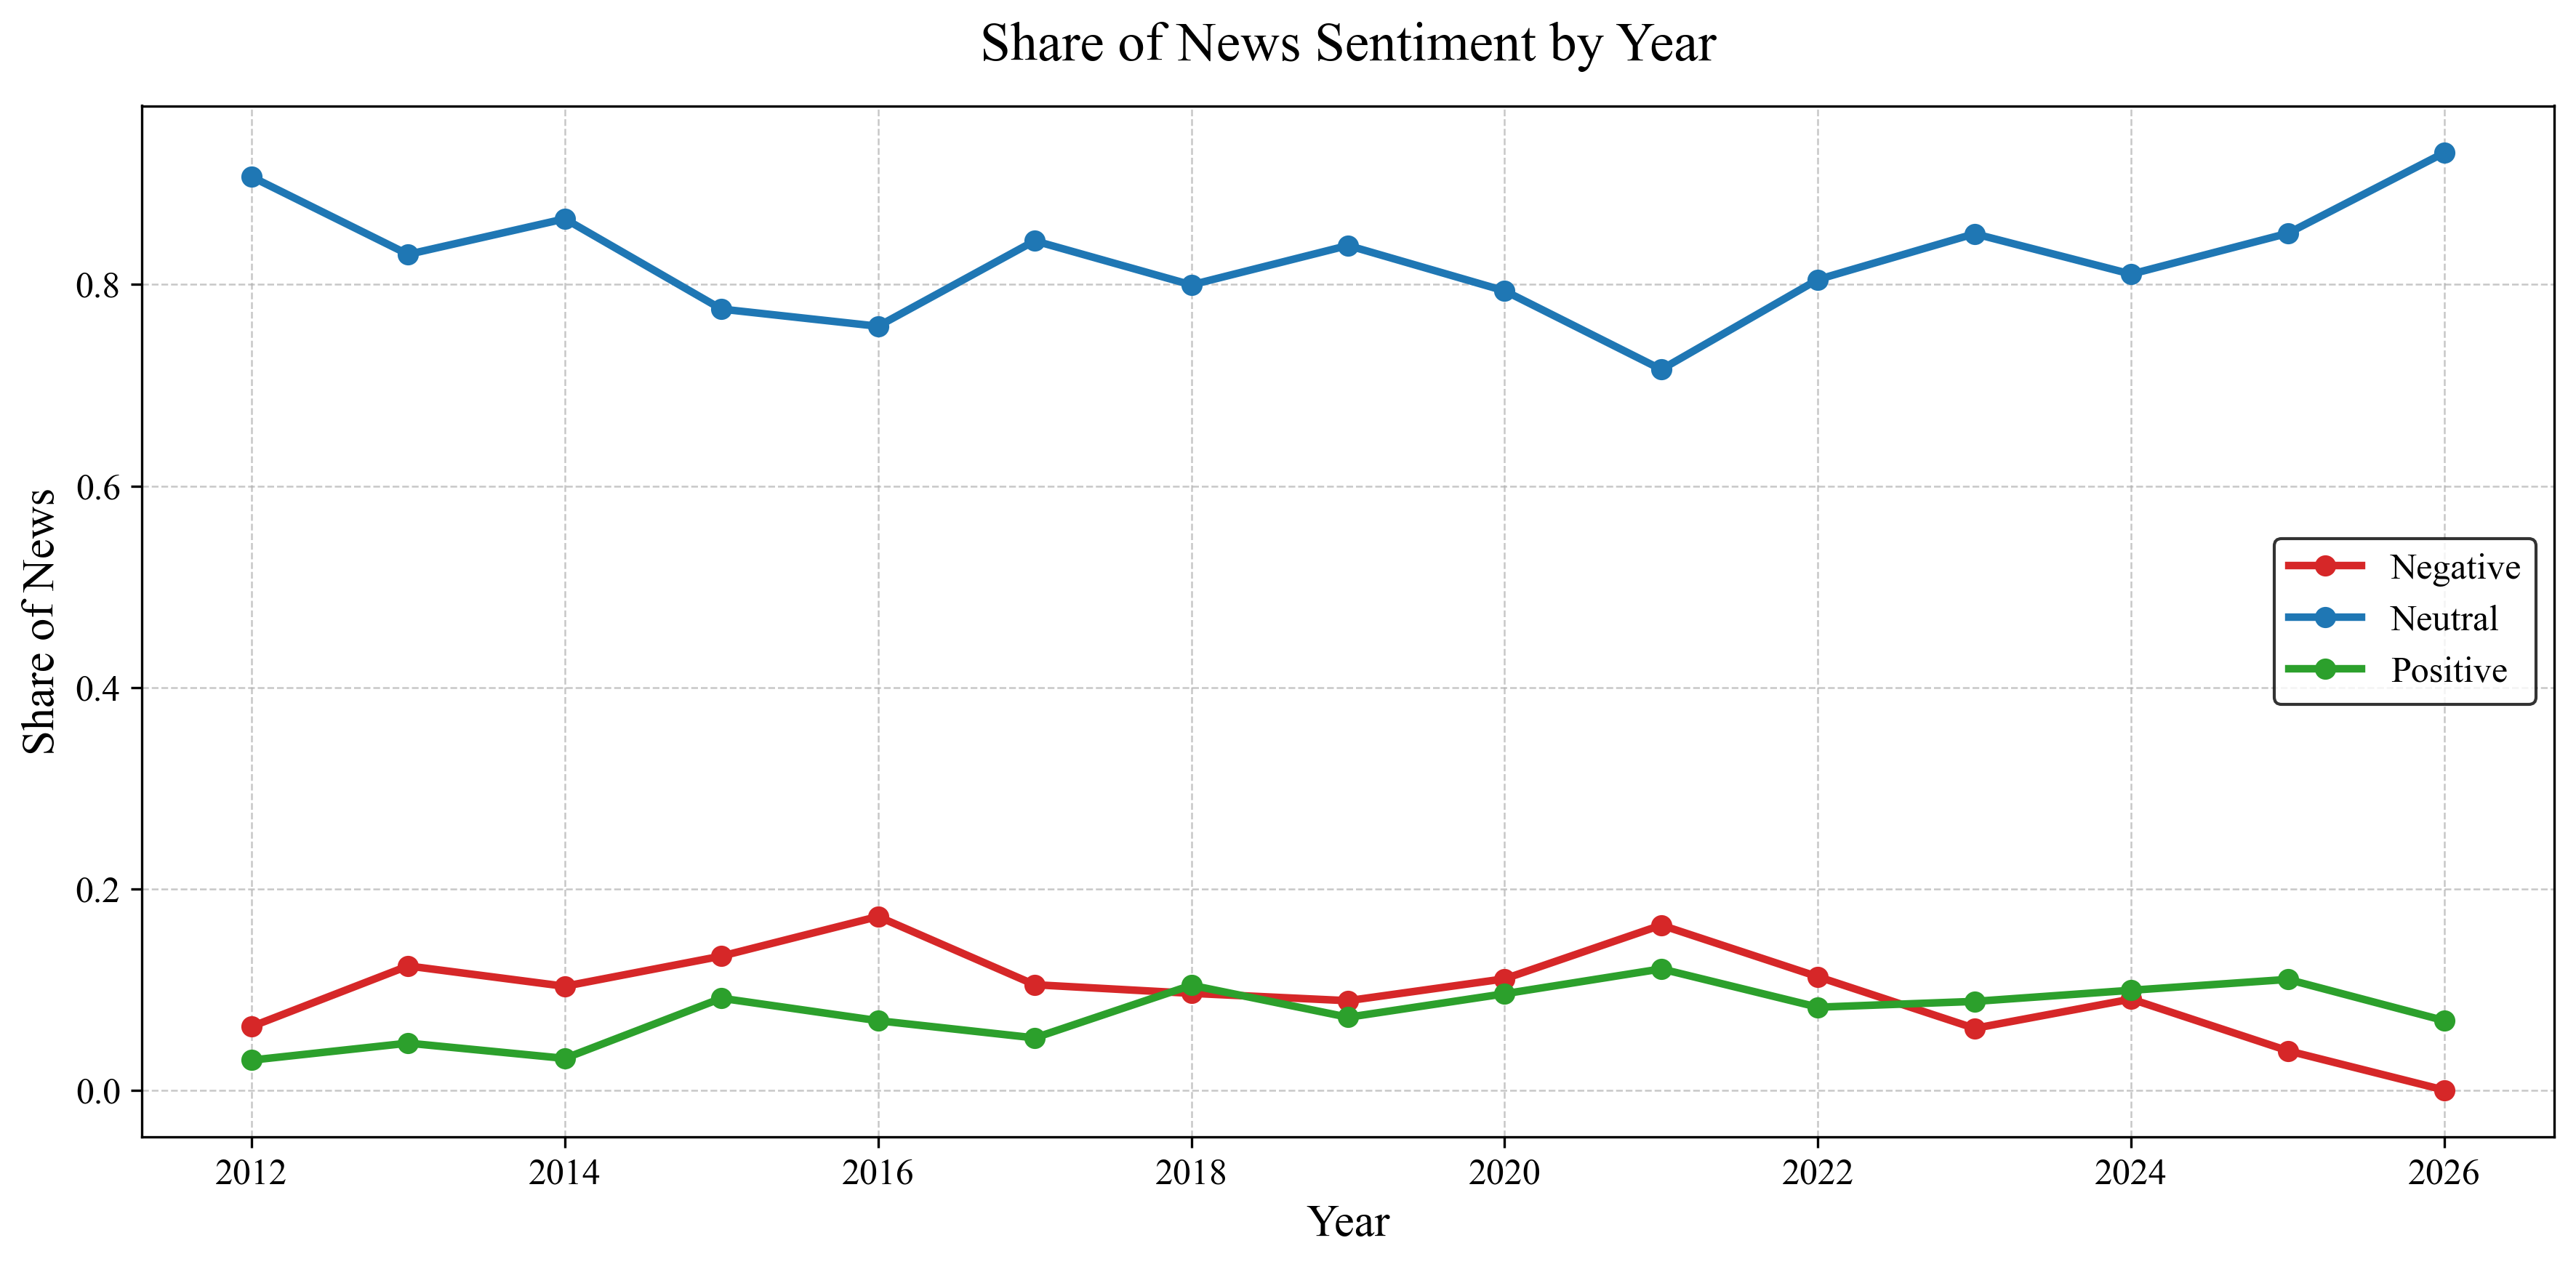

In [4]:
plt.style.use('default')

plt.rcParams.update({
    'font.family': 'Times New Roman',
    'font.size': 13,
    'axes.titlesize': 18,
    'axes.labelsize': 15,
    'legend.fontsize': 12,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12
})

df['date'] = pd.to_datetime(df['date'])

yearly_counts = (
    df.groupby([pd.Grouper(key='date', freq='Y'), 'sentiment'])
    .size()
    .unstack(fill_value=0)
)

total_news = yearly_counts.sum(axis=1)
yearly_share = yearly_counts.div(total_news, axis=0)

colors = {
    'negative': '#d62728',
    'neutral': '#1f77b4',
    'positive': '#2ca02c'
}

fig, ax = plt.subplots(figsize=(12, 6), dpi=300)

for col in yearly_share.columns:
    ax.plot(
        yearly_share.index.year,
        yearly_share[col],
        marker='o',
        markersize=6,
        linewidth=2.5,
        label=col.capitalize(),
        color=colors[col]
    )

ax.set_title(
    'Share of News Sentiment by Year',
    pad=15
)

ax.set_xlabel('Year')
ax.set_ylabel('Share of News')

ax.grid(
    True,
    linestyle='--',
    linewidth=0.6,
    alpha=0.7
)

ax.legend(
    frameon=True,
    edgecolor='black',
    facecolor='white'
)

plt.tight_layout()

plt.show()

### Topic Analysis

In [5]:
pd.reset_option('display.max_colwidth')

In [6]:
df = pd.read_csv('topics.csv')

Top-5 negative topics

In [7]:
top5_negative = df.nlargest(5, 'negative_pct')

top5_negative

,topic_id,n_docs,positive_pct,negative_pct,top_words_positive,top_words_negative,top3_positive_titles,top3_negative_titles
16,16,226,0.4,67.3,"рынок, индекс, который, рост, позитивный, пунк...","индекс, долл, рынок, пункт, торг, фондовый, бы...",Новогодний оптимизм может оказаться непрочным,Рост на бирже сменился снижением | Биржа колеб...
15,15,244,0.0,63.5,NaN,"быть, рынок, банк, торг, который, брокер, клие...",NaN,- | - | Мосбиржа опровергла сообщения о недост...
6,6,465,0.0,58.1,NaN,"долл, уровень, торговый, закрытие, предыдущий,...",NaN,Динамика цен на нефть дает силы рублю | Доллар...
37,38,105,0.0,37.1,NaN,"копейка, московский, биржа, банк, рынок, интер...",NaN,СМИ нашли причину рекордного обвала рубля | СМ...
24,24,151,1.3,33.8,"сегодня, индекс, котировка, нефть, максимум, р...","сегодня, индекс, рынок, российский, рост, нефт...",До конца дня на российском фондовом рынке сохр...,Сегодня вряд ли стоит ожидать улучшения настро...


In [8]:
news = pd.read_csv('df_with_topics_and_sentiments.csv')

In [9]:
pd.set_option('display.max_colwidth', 50)

In [10]:
news = news.drop(columns=['Unnamed: 0.2', 'Unnamed: 0.1', 'Unnamed: 0'])

In [11]:
news.loc[news['topic'].isin([5, 10, 20 ]), 'topic'] = 'ключевая ставка'
news.loc[news['topic'].isin([7, 9, 11, 13, 18, 23]), 'topic'] = 'нефть'
news.loc[news['topic'].isin([2, 8, 14, 15, 32, 40]), 'topic'] = 'акции'
news.loc[news['topic'].isin([12, 15]), 'topic'] = 'санкции'
news.loc[news['topic'].isin([30]), 'topic'] = 'недвижимость'

/var/folders/k8/hm4dhr791436k27_z9b877qr0000gn/T/ipykernel_66048/1896653417.py:1: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value 'ключевая ставка' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  news.loc[news['topic'].isin([5, 10, 20 ]), 'topic'] = 'ключевая ставка'


In [12]:
subset = news[
    (news['topic'].apply(lambda x: not str(x).isdigit())) &
    (news['topic'] != -1)
]

In [13]:
subset['topic'].value_counts()

topic
нефть              1748
акции              1622
ключевая ставка    1007
санкции             304
недвижимость        124
Name: count, dtype: int64

In [14]:
subset.head()

,title,link,date,text,source,tokens,tokens_str,topic,sentiment
1,Курс доллара поднялся выше 36 рублей,https://russian.rt.com/article/27673,2014-04-14 00:00:00,Ситуация на внутреннем валютном рынке обострил...,rt,"['ситуация', 'внутренний', 'рынок', 'обострить...",ситуация внутренний рынок обостриться фон эска...,санкции,neutral
5,Эльвира Набиуллина: Ограничений на обмен валют...,https://russian.rt.com/article/54159,2014-10-13 00:00:00,"Отметим, рубль этой осенью переживает очередно...",rt,"['отметить', 'этот', 'осень', 'переживать', 'о...",отметить этот осень переживать очередной виток...,нефть,neutral
12,Банк России отказался от регулярных валютных и...,https://russian.rt.com/article/58772,2014-11-10 00:00:00,"По словам Набиуллиной, в последние дни на валю...",rt,"['набиуллин', 'последний', 'рынок', 'наблюдать...",набиуллин последний рынок наблюдаться напрячь ...,ключевая ставка,neutral
27,Аналитики: Повышение ключевой ставки ЦБ до 17%...,https://russian.rt.com/article/64673,2014-12-16 00:00:00,Повышение ключевой ставки Центробанком до 17% ...,rt,"['повышение', 'ключевой', 'ставка', 'центробан...",повышение ключевой ставка центробанк годовой о...,ключевая ставка,neutral
28,Минфин: Курс рубля нашёл своё равновесное поло...,https://russian.rt.com/article/71534,2015-01-30 00:00:00,«Когда принимались решения о повышении (ключев...,rt,"['когда', 'приниматься', 'решение', 'повышение...",когда приниматься решение повышение ключевой с...,ключевая ставка,neutral


In [15]:
subset = subset.copy()

subset['date'] = pd.to_datetime(subset['date'], errors='coerce')
subset = subset.dropna(subset=['date'])

subset['month'] = subset['date'].dt.to_period('M').astype(str)

total_news = (
    subset.groupby('month')
    .size()
    .rename('total')
)

topic_counts = (
    subset.groupby(['month', 'topic'])
    .size()
    .unstack(fill_value=0)
)

topic_by_month = (
    pd.concat([total_news, topic_counts], axis=1)
    .reset_index()
)

topic_by_month = topic_by_month.rename(columns={
    'нефть': 'oil',
    'акции': 'stocks',
    'санкции': 'sanctions',
    'ключевая ставка': 'key_rate',
    'недвижимость': 'real_estate'
})

topic_by_month.head()

,month,total,stocks,key_rate,real_estate,oil,sanctions
0,2012-02,2,0,1,0,1,0
1,2012-03,2,0,0,2,0,0
2,2012-06,4,0,0,3,1,0
3,2012-07,2,1,1,0,0,0
4,2012-08,2,0,1,0,0,1


In [16]:
topic_by_month['total'].sum()

4805

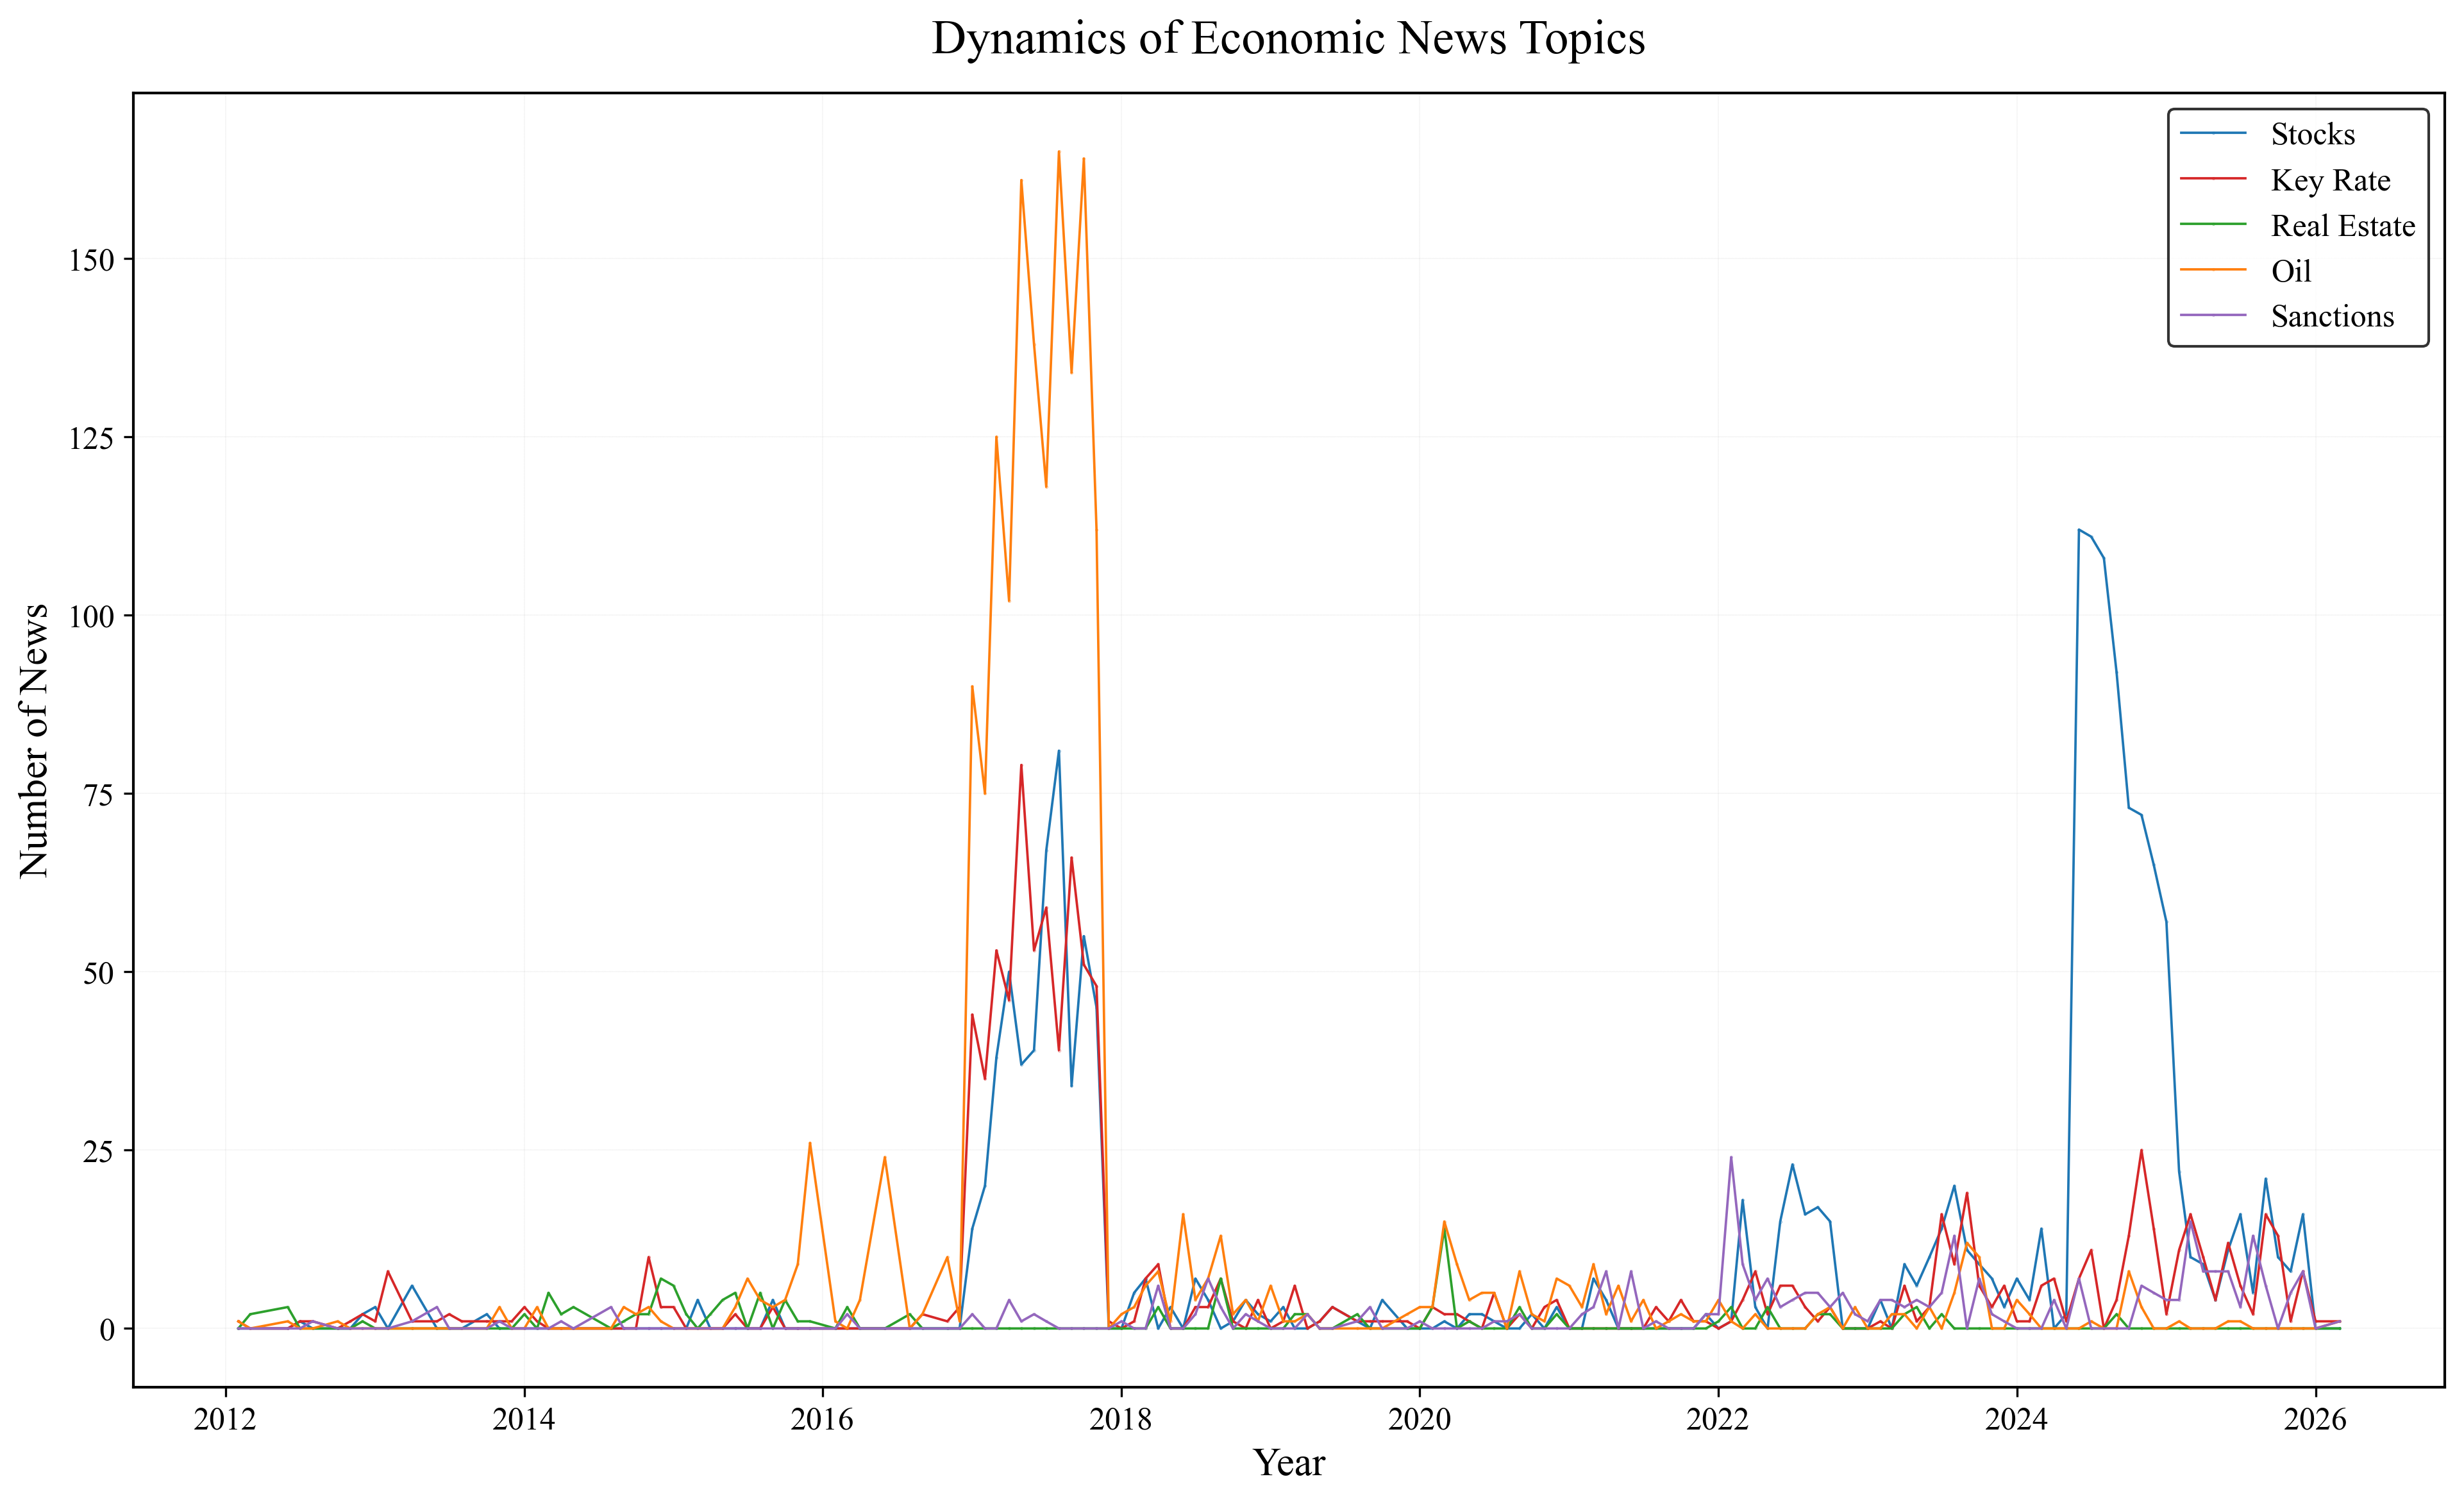

In [ ]:
topic_by_month['month'] = pd.to_datetime(topic_by_month['month'])

plt.style.use('default')

plt.rcParams.update({
    'font.family': 'Times New Roman',
    'font.size': 13,
    'axes.titlesize': 18,
    'axes.labelsize': 15,
    'legend.fontsize': 12,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12
})

colors = {
    'stocks': '#1f77b4',
    'key_rate': '#d62728',
    'real_estate': '#2ca02c',
    'oil': '#ff7f0e',
    'sanctions': '#9467bd'
}

fig, ax = plt.subplots(figsize=(13, 8), dpi=300)

for col in ['stocks', 'key_rate', 'real_estate', 'oil', 'sanctions']:
    ax.plot(
        topic_by_month['month'],
        topic_by_month[col],
        marker='o',
        linewidth=0.9,
        markersize=0.1,
        label=col.replace('_', ' ').title(),
        color=colors[col]
    )

ax.set_title(
    'Dynamics of Economic News Topics',
    pad=15
)

ax.set_xlabel('Year')
ax.set_ylabel('Number of News')

ax.grid(
    True,
    linestyle='--',
    linewidth=0.1,
    alpha=0.7
)

for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(1)
    spine.set_color('black')

ax.legend(
    frameon=True,
    edgecolor='black',
    facecolor='white'
)

plt.tight_layout()

plt.show()

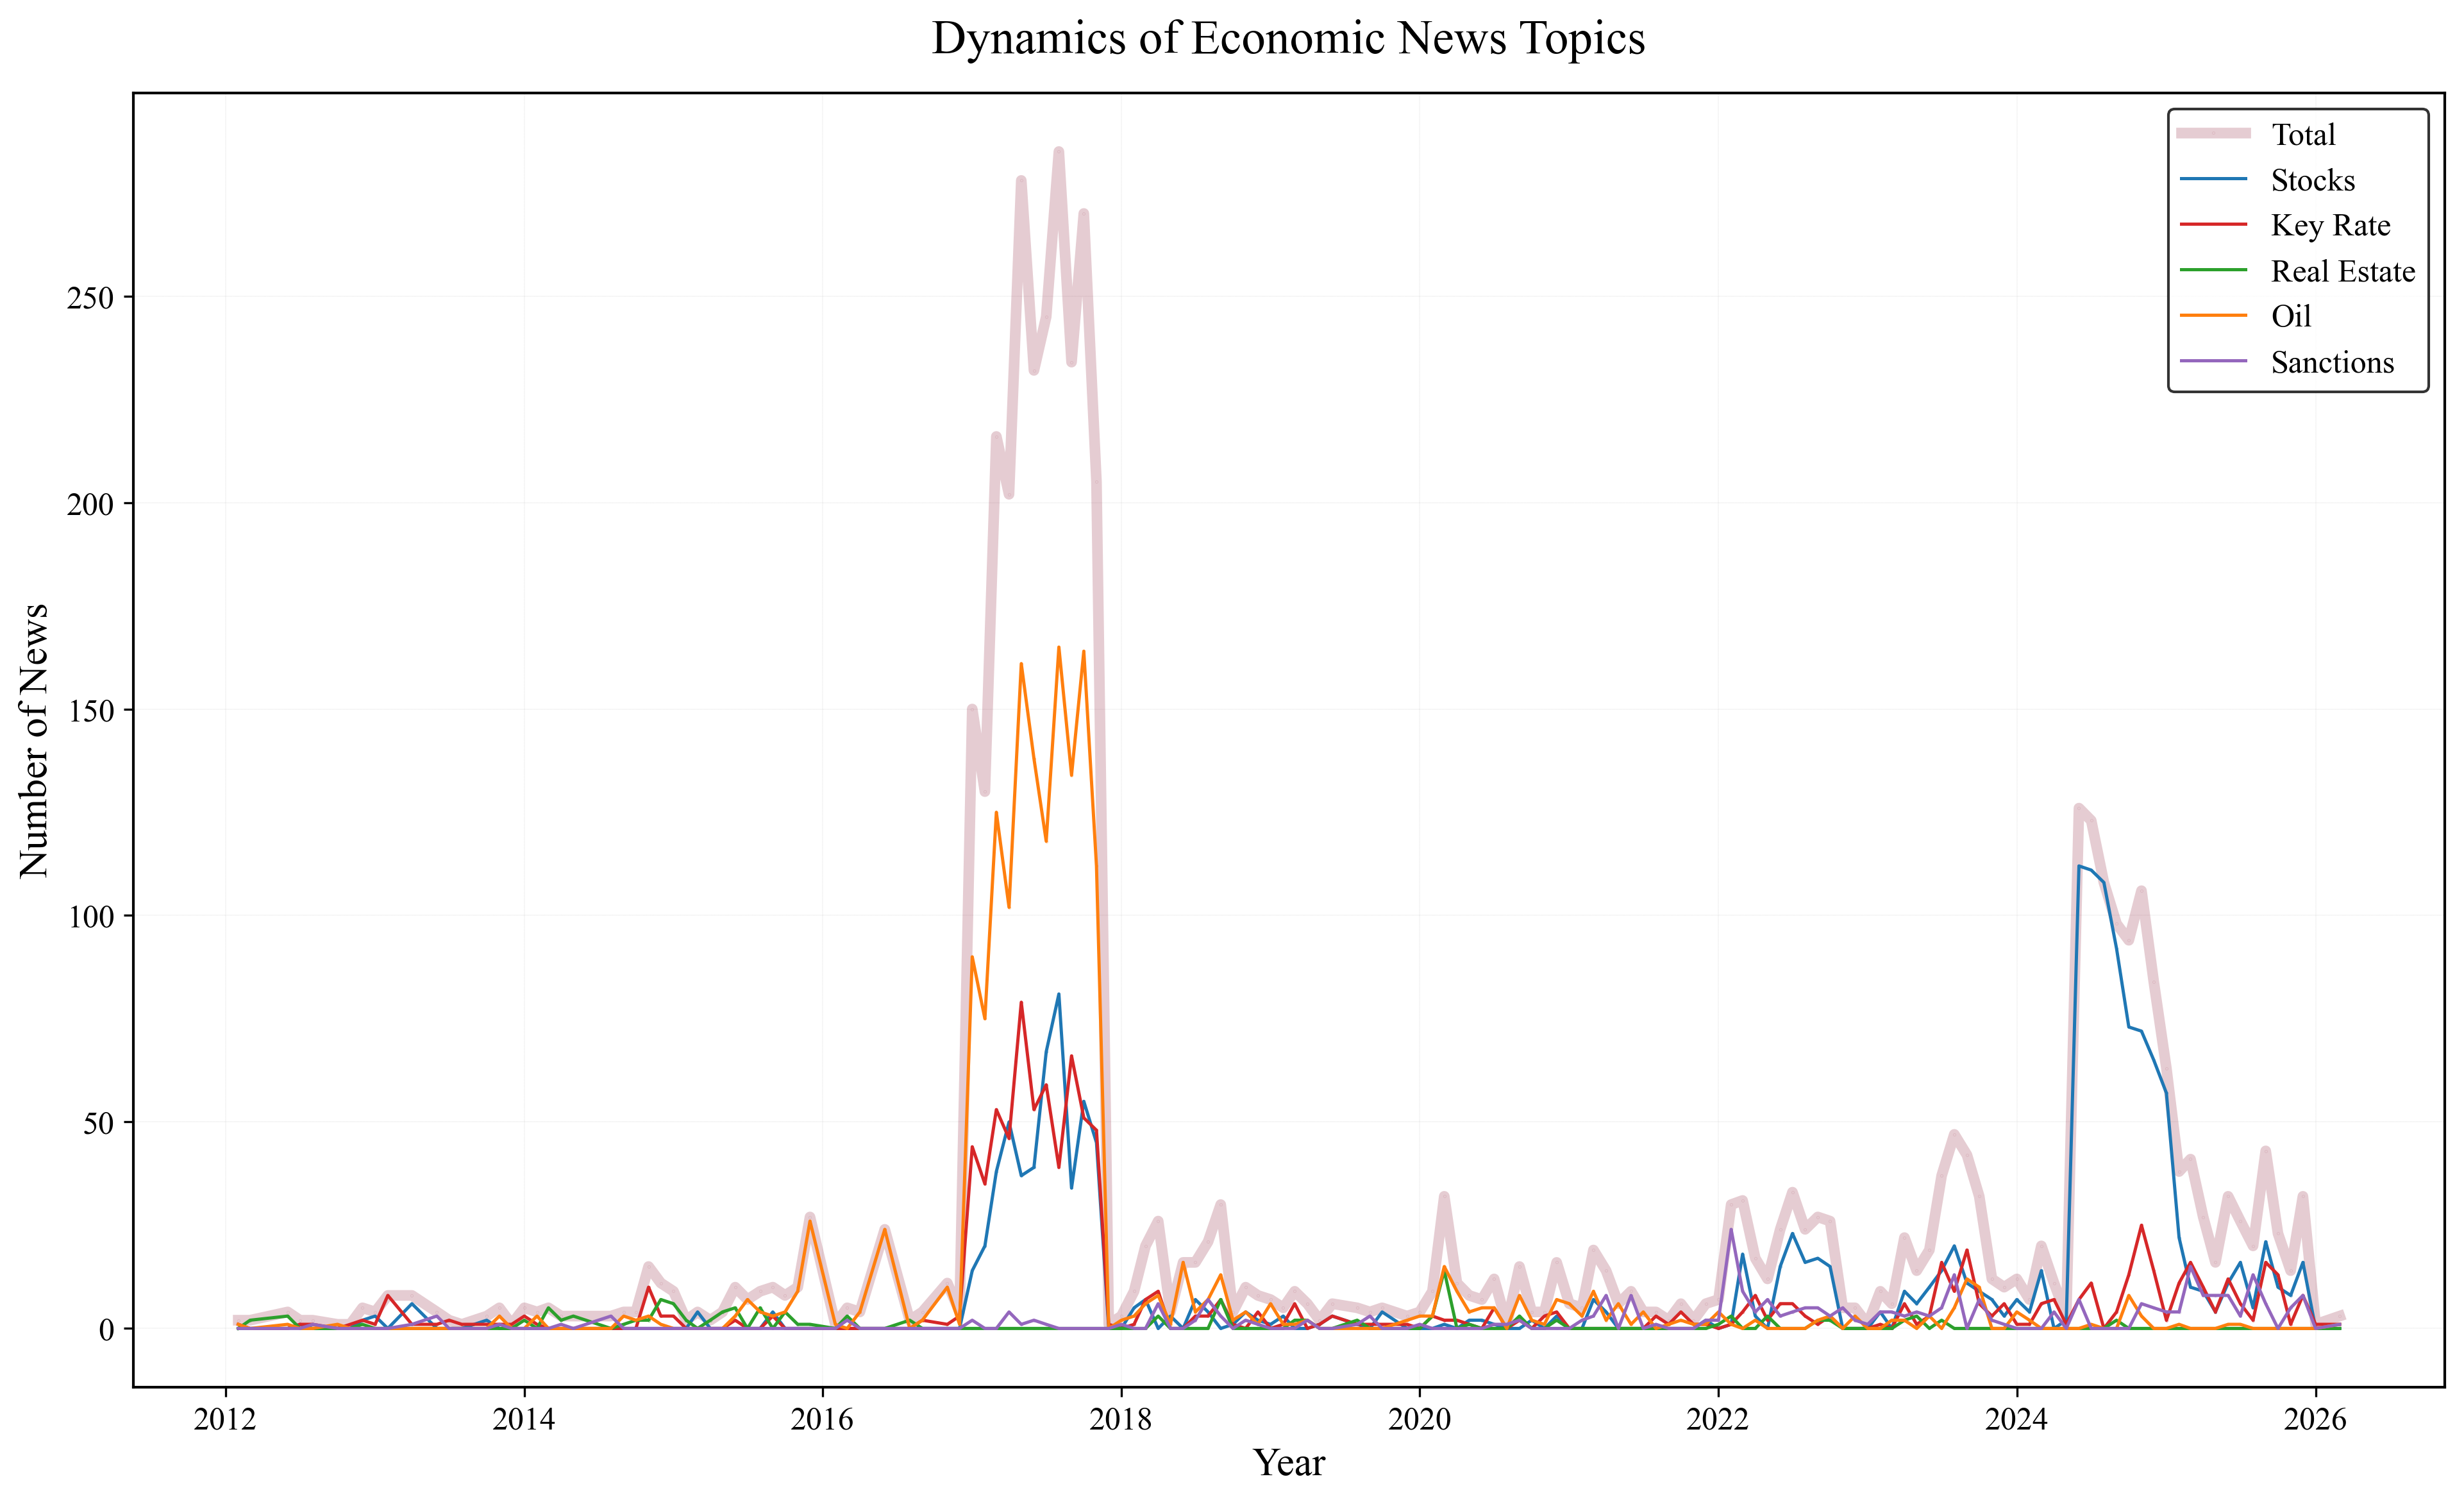

In [21]:
topic_by_month['month'] = pd.to_datetime(topic_by_month['month'])

plt.style.use('default')

plt.rcParams.update({
    'font.family': 'Times New Roman',
    'font.size': 13,
    'axes.titlesize': 18,
    'axes.labelsize': 15,
    'legend.fontsize': 12,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12
})

colors = {
    'total': '#800020',
    'stocks': '#1f77b4',
    'key_rate': '#d62728',
    'real_estate': '#2ca02c',
    'oil': '#ff7f0e',
    'sanctions': '#9467bd'
}

fig, ax = plt.subplots(figsize=(13, 8), dpi=300)

for col in ['total', 'stocks', 'key_rate', 'real_estate', 'oil', 'sanctions']:
    ax.plot(
        topic_by_month['month'],
        topic_by_month[col],
        marker='o',
        linewidth=1.2 if col != 'total' else 4,
        alpha=0.2 if col == 'total' else 1,
        markersize=0.1, 
        label=col.replace('_', ' ').title(),
        color=colors[col]
    )

ax.set_title(
    'Dynamics of Economic News Topics',
    pad=15
)

ax.set_xlabel('Year')
ax.set_ylabel('Number of News')

ax.grid(
    True,
    linestyle='--',
    linewidth=0.1,
    alpha=0.7
)

for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(1)
    spine.set_color('black')

ax.legend(
    frameon=True,
    edgecolor='black',
    facecolor='white'
)

plt.tight_layout()

plt.show()

In [22]:
l = [1, 2, 3, 4, 5, 6, 8]

print(sorted(l)[-2:])

[6, 8]


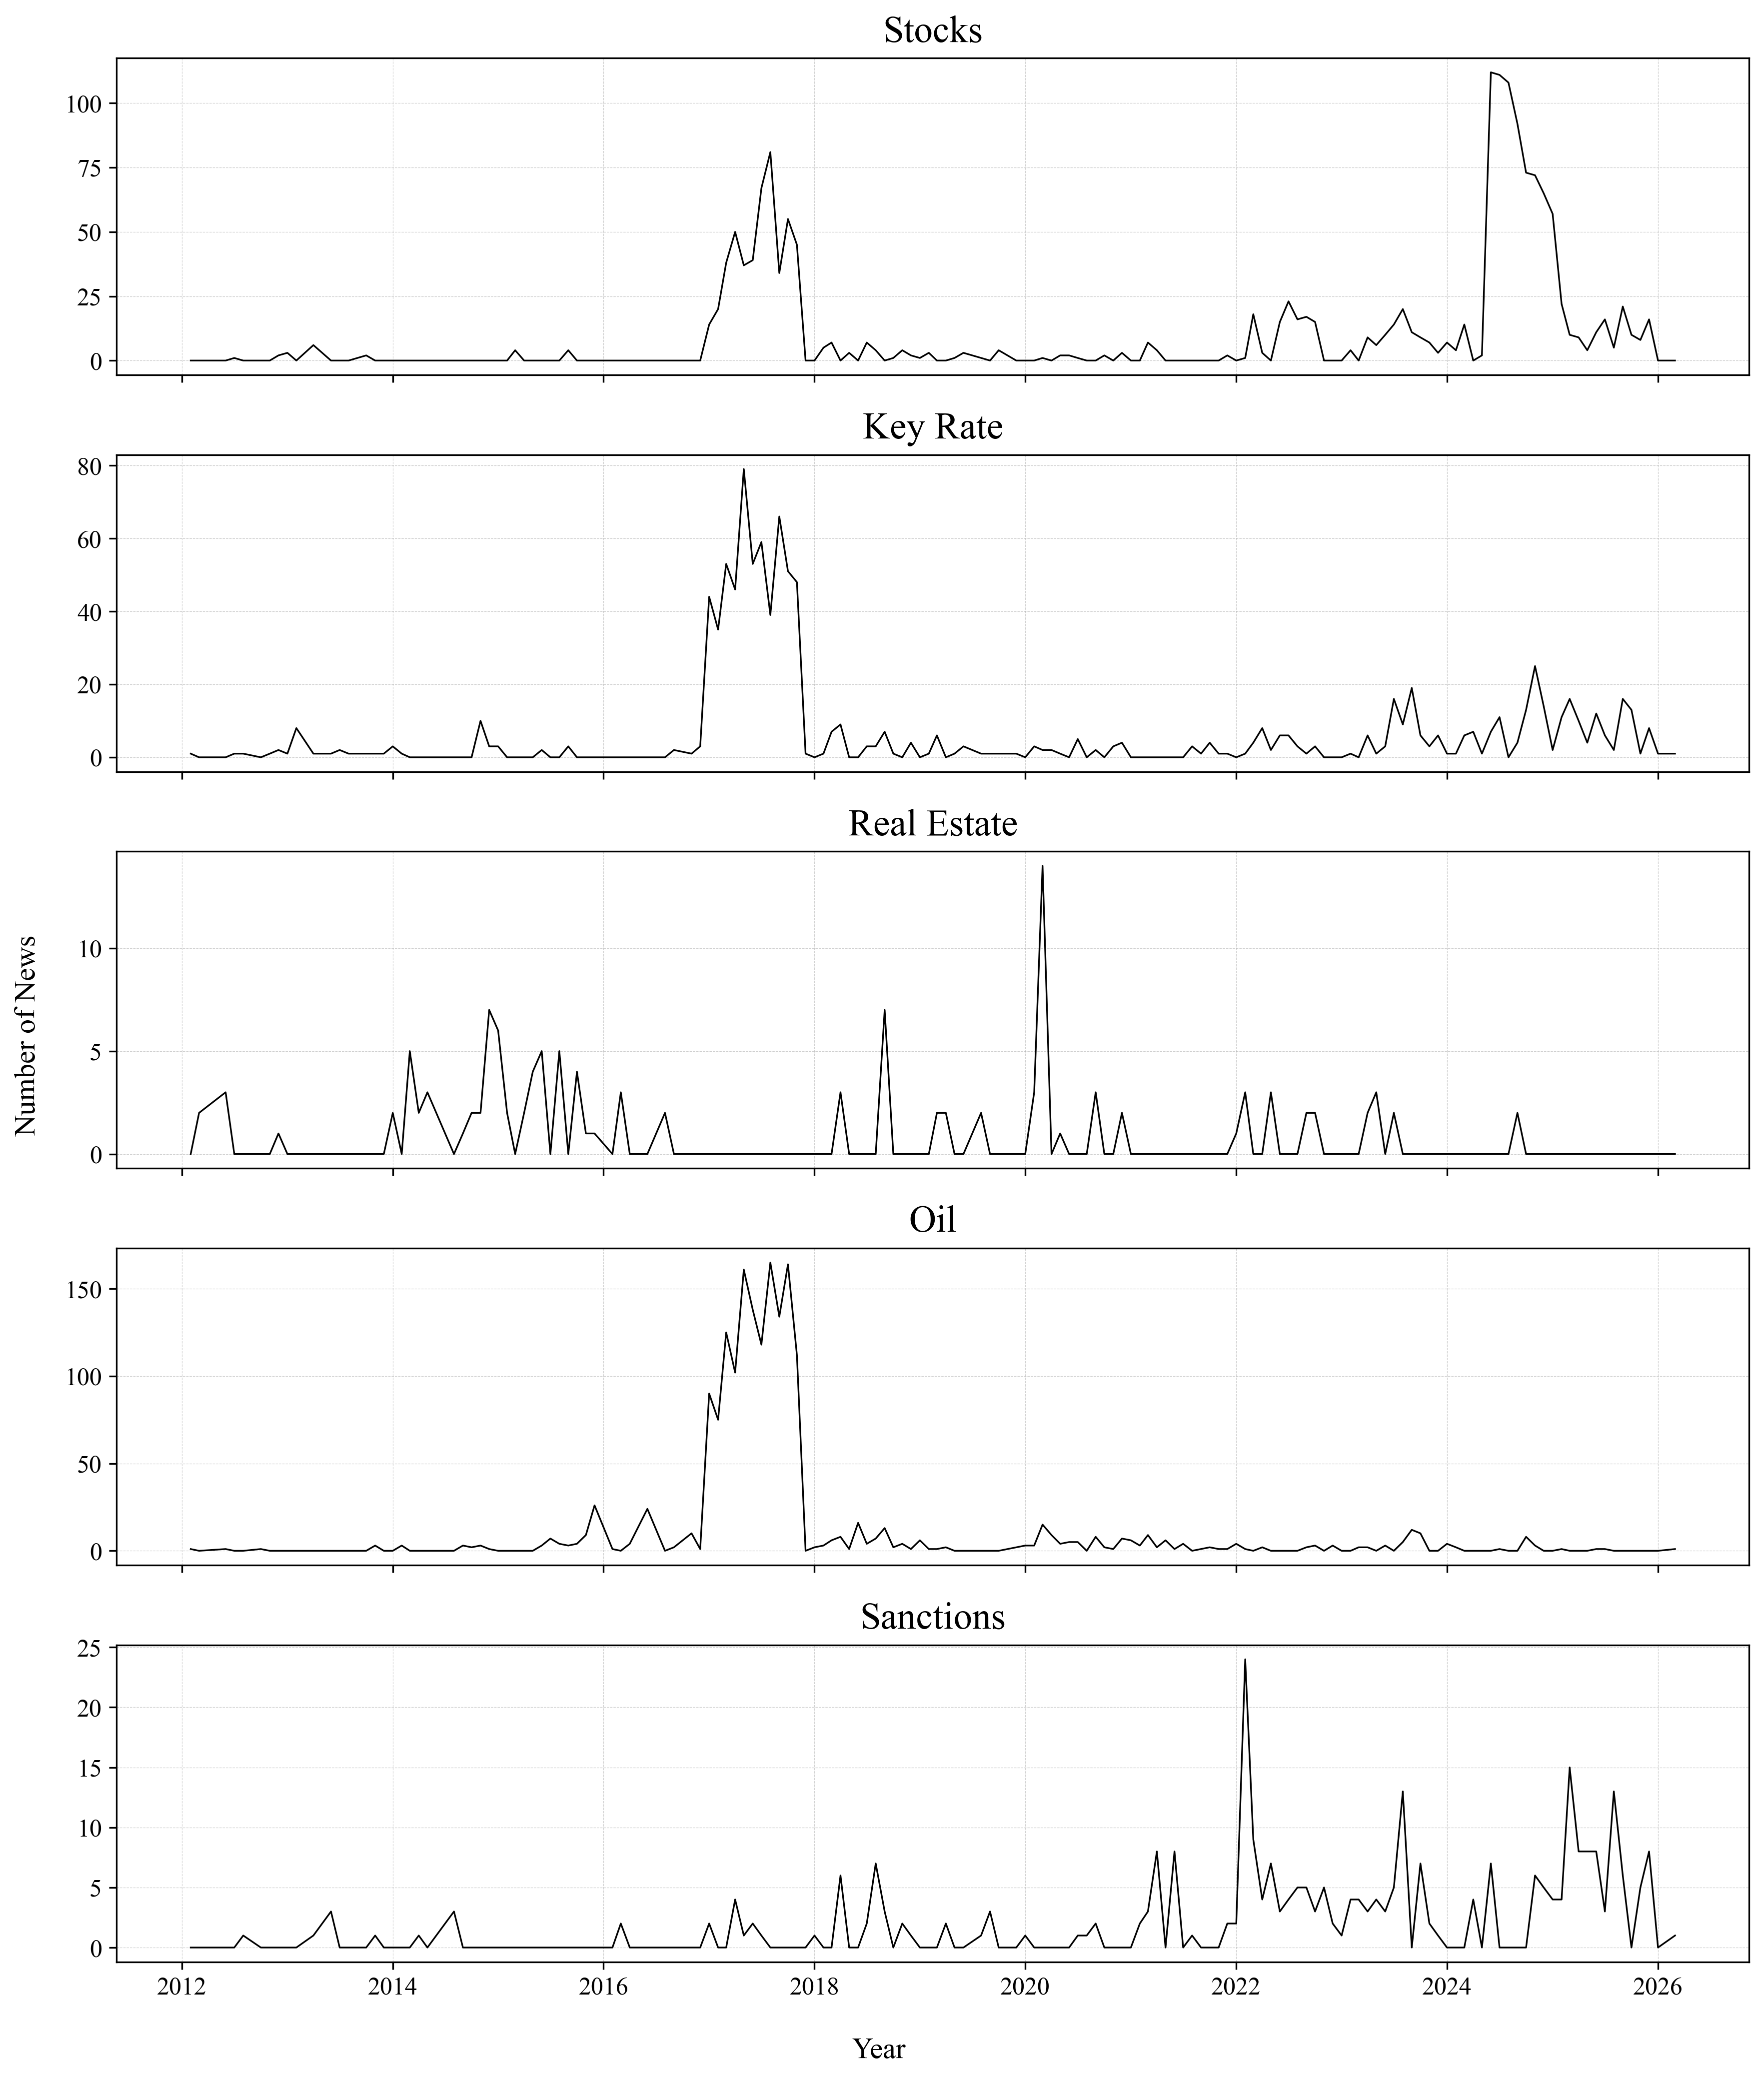

In [24]:
topic_by_month['month'] = pd.to_datetime(topic_by_month['month'])

plt.style.use('default')

plt.rcParams.update({
    'font.family': 'Times New Roman',
    'font.size': 13,
    'axes.titlesize': 18,
    'axes.labelsize': 15,
    'legend.fontsize': 12,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12
})

topics = [
    'stocks',
    'key_rate',
    'real_estate',
    'oil',
    'sanctions'
]

titles = {
    'stocks': 'Stocks',
    'key_rate': 'Key Rate',
    'real_estate': 'Real Estate',
    'oil': 'Oil',
    'sanctions': 'Sanctions'
}

fig, axes = plt.subplots(
    5, 1,
    figsize=(12, 14),
    dpi=300,
    sharex=True
)

for ax, topic in zip(axes, topics):

    ax.plot(
        topic_by_month['month'],
        topic_by_month[topic],
        color='black',
        linewidth=0.8
    )

    ax.set_title(titles[topic], pad=8)

    ax.grid(
        True,
        linestyle='--',
        linewidth=0.3,
        alpha=0.6
    )

    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_linewidth(0.8)
        spine.set_color('black')

fig.supxlabel('Year', fontsize=14)
fig.supylabel('Number of News', fontsize=14)

plt.tight_layout()

plt.show()

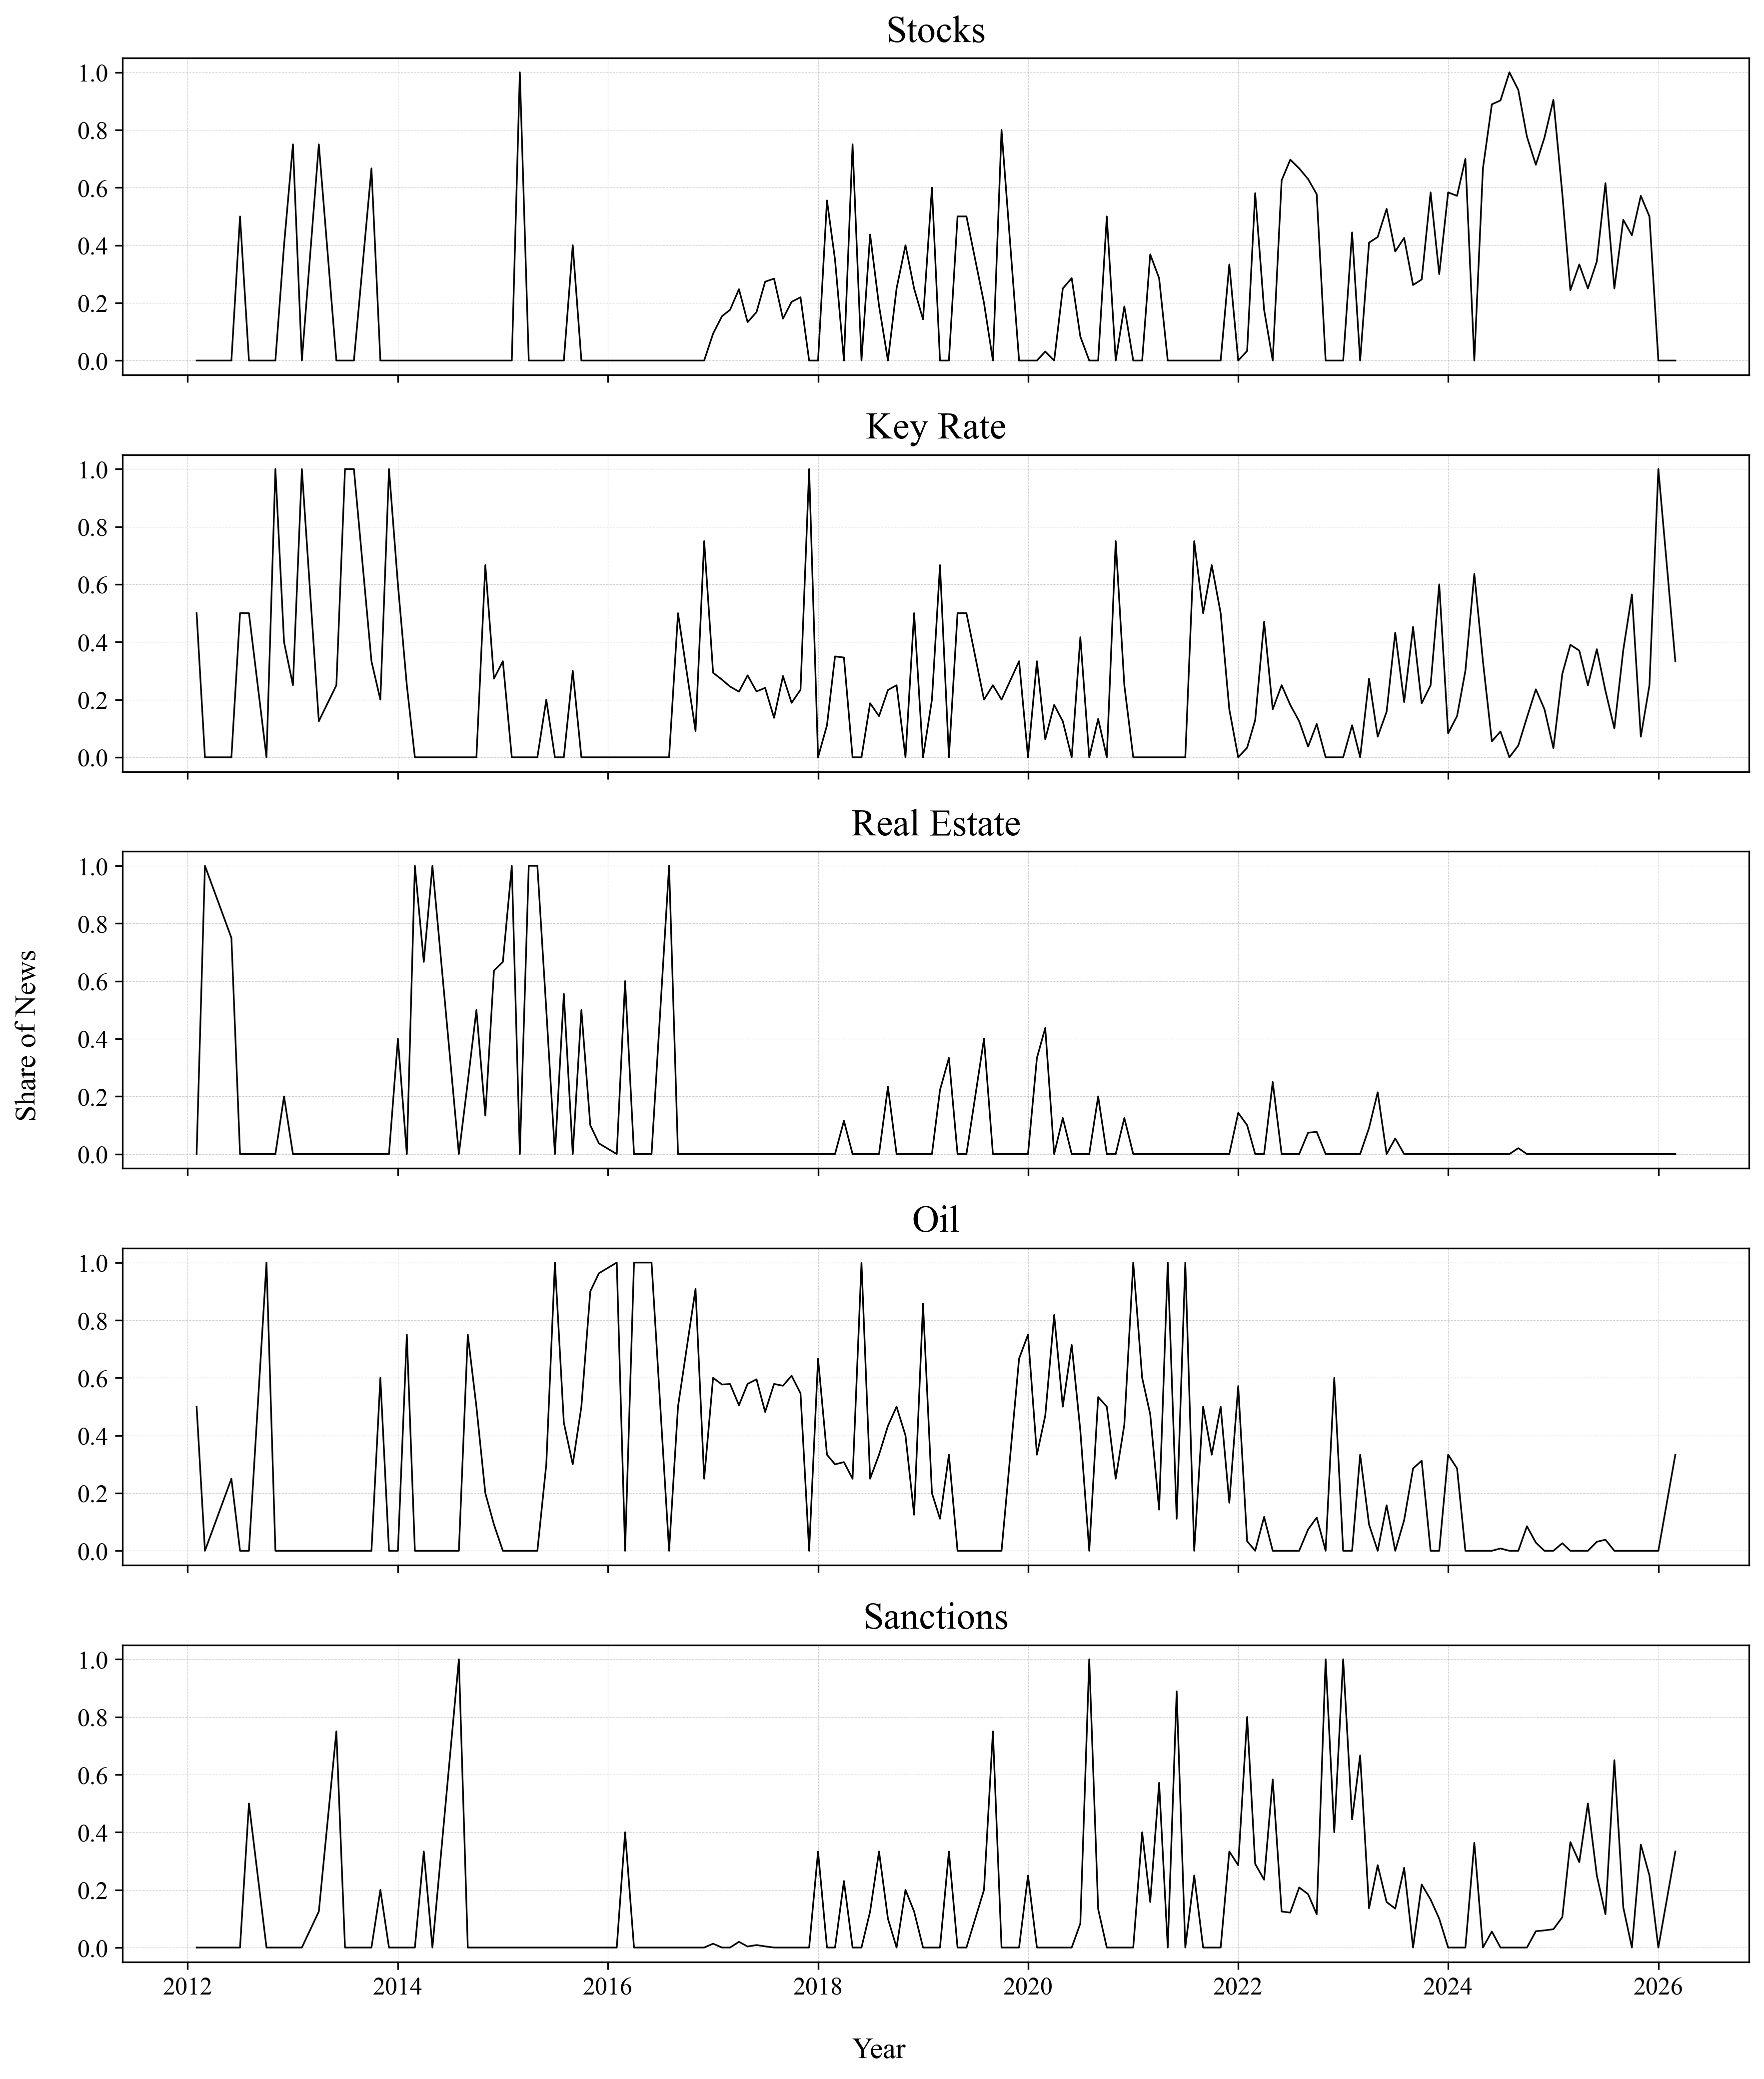

In [25]:
topic_by_month['month'] = pd.to_datetime(topic_by_month['month'])

share_df = topic_by_month.copy()

topics = [
    'stocks',
    'key_rate',
    'real_estate',
    'oil',
    'sanctions'
]

for topic in topics:
    share_df[topic] = share_df[topic] / share_df['total']

plt.style.use('default')

plt.rcParams.update({
    'font.family': 'Times New Roman',
    'font.size': 13,
    'axes.titlesize': 18,
    'axes.labelsize': 15,
    'legend.fontsize': 12,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12
})

titles = {
    'stocks': 'Stocks',
    'key_rate': 'Key Rate',
    'real_estate': 'Real Estate',
    'oil': 'Oil',
    'sanctions': 'Sanctions'
}

fig, axes = plt.subplots(
    5, 1,
    figsize=(12, 14),
    dpi=300,
    sharex=True
)

for ax, topic in zip(axes, topics):

    ax.plot(
        share_df['month'],
        share_df[topic],
        color='black',
        linewidth=0.8
    )

    ax.set_title(titles[topic], pad=8)

    ax.grid(
        True,
        linestyle='--',
        linewidth=0.3,
        alpha=0.6
    )

    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_linewidth(0.8)
        spine.set_color('black')

fig.supxlabel('Year', fontsize=14)
fig.supylabel('Share of News', fontsize=14)

plt.tight_layout()

plt.show()

In [112]:
topic_by_month.to_csv('topic_by_month.csv')